# Component 4 — Agency-banking anomaly detection: full pipeline

One notebook, from raw data to the research result. It joins three notebooks, kept unchanged in `archive/`:

| Part | Was in | What it does |
|---|---|---|
| A. Train the model | `agency banking.ipynb` | clean data, split, Isolation Forest feature, compare 4 models, pick XGBoost |
| B. Choose the threshold | `agency_banking_threshold.ipynb` | choose the probability cut-off on training data only (0.5 → ~0.87) |
| C. Rules vs ML vs hybrid | `agency_banking_hybrid.ipynb` | compare the model with the CBSL rule, a z-score rule and a naive baseline |
| D. Training/serving check | new | does the app compute the inputs the way the training data did? |
| E. Save the model | `agency banking.ipynb` | saved under a new name |

**Research question.** For flagging suspicious agency-banking transactions, is the ML model better than
simple rules, and should the CBSL rule be combined with it?

The model is retrained here; part A checks that it is the same model as the saved
`component4_banking_anomaly_model.pkl`. A new model file is saved under a **new name**; the original
`.pkl`, `paysim.csv` and the three notebooks are not changed.

# Part A — Train the model  *(from `agency banking.ipynb`)*

In [1]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    GradientBoostingClassifier,
    IsolationForest,
    RandomForestClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Ignore unnecessary warning messages during model training
warnings.filterwarnings('ignore')

print('====================================================================')
print('=== COMPONENT 4: AGENCY BANKING HYBRID FRAUD DETECTION ANALYTICS ===')
print('====================================================================\n')

=== COMPONENT 4: AGENCY BANKING HYBRID FRAUD DETECTION ANALYTICS ===



## A1. Load and clean the data

In [2]:
# =========================================================================
# STEP 1: DATA LOADING & PRELIMINARY CLEANING
# =========================================================================
# Load transaction dataset
df = pd.read_csv('paysim.csv')

# Drop duplicate records to avoid model bias
df = df.drop_duplicates().reset_index(drop=True)

# Drop non-predictive identifiers and raw timestamp columns safely
df = df.drop(columns=['bank_txn_id', 'date'], errors='ignore')

## A2. Feature: extreme amount (|z-score| > 2)

In [3]:
# =========================================================================
# STEP 2: ADVANCED FEATURE ENGINEERING (PRE-SPLIT SAFE FEATURES)
# =========================================================================
# Feature Engineering A: Z-Score Outlier Check for Extreme Amounts
if 'amount_zscore' in df.columns:
    df['is_high_zscore'] = (df['amount_zscore'].abs() > 2.0).astype(int)

## A3. Target, features and the 80/20 stratified train/test split

The split is done first, so nothing from the test set is used to build features or choose anything.

In [4]:
# =========================================================================
# STEP 3: TARGET & FEATURE DEFINITION AND TRAIN-TEST SPLIT
# =========================================================================
# Separate dependent target variable (y) and independent features (X)
y = df['target_anomaly'].astype(int)
X = df.drop(columns=['target_anomaly'])

# Print baseline anomaly distribution
anomaly_rate = y.mean() * 100
print(f'Dataset Size     : {len(df)} transactions')
print(f'Anomaly Rate     : {anomaly_rate:.2f}%\n')

# Perform 80/20 Stratified Train-Test Split (FIRST to avoid Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Make explicit copies to avoid SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

Dataset Size     : 164260 transactions
Anomaly Rate     : 5.00%



## A4. Isolation Forest score as an extra feature (fitted on training data only)

In [5]:
# =========================================================================
# STEP 4: UNSUPERVISED ISOLATION FOREST ANOMALY SCORING (NO LEAKAGE)
# =========================================================================
# Extract numerical columns for unsupervised anomaly detection
iso_num_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

# Impute missing numerical values before running Isolation Forest
iso_imputer = SimpleImputer(strategy='median')
X_train_num_imp = iso_imputer.fit_transform(X_train[iso_num_cols])
X_test_num_imp = iso_imputer.transform(X_test[iso_num_cols])

# Train Isolation Forest on TRAIN DATA ONLY
iso_forest = IsolationForest(
    n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1
)
iso_forest.fit(X_train_num_imp)

# Generate anomaly scores (-1 = Outlier -> 1, 1 = Normal -> 0)
X_train['unsupervised_anomaly_score'] = (
    iso_forest.predict(X_train_num_imp) == -1
).astype(int)
X_test['unsupervised_anomaly_score'] = (
    iso_forest.predict(X_test_num_imp) == -1
).astype(int)

## A5. Preprocessing and the four candidate models

`scale_pos_weight` (≈ 19) makes XGBoost pay more attention to the rare anomalies (5 %).

In [6]:
# =========================================================================
# STEP 5: PREPROCESSING PIPELINE SETUP
# =========================================================================
# Separate categorical and numerical feature columns
cat_cols = ['txn_type', 'direction', 'channel']
cat_cols = [c for c in cat_cols if c in X_train.columns]
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Define Scikit-Learn Pipeline ColumnTransformer for scaling & encoding
preprocessor = ColumnTransformer([
    (
        'cat',
        Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore')),
        ]),
        cat_cols,
    ),
    (
        'num',
        Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc', StandardScaler()),
        ]),
        num_cols,
    ),
])

# Calculate scale_pos_weight for handling class imbalance in gradient boosting
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define dictionary of classification algorithms wrapped in Scikit-Learn Pipelines
models = {
    'LogisticRegression': Pipeline([
        ('pre', preprocessor),
        (
            'm',
            LogisticRegression(
                max_iter=1000, class_weight='balanced', random_state=42
            ),
        ),
    ]),
    'DecisionTree': Pipeline([
        ('pre', preprocessor),
        (
            'm',
            DecisionTreeClassifier(
                max_depth=8, class_weight='balanced', random_state=42
            ),
        ),
    ]),
    'RandomForest': Pipeline([
        ('pre', preprocessor),
        (
            'm',
            RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]),
}

# Optional XGBoost Integration if library is installed in local environment
try:
    from xgboost import XGBClassifier

    models['XGBoost'] = Pipeline([
        ('pre', preprocessor),
        (
            'm',
            XGBClassifier(
                n_estimators=300,
                max_depth=5,
                learning_rate=0.1,
                subsample=0.9,
                scale_pos_weight=scale_pos_weight,
                eval_metric='logloss',
                random_state=42,
            ),
        ),
    ])
except ImportError:
    print('Notice: XGBoost not installed. Training with sklearn models.')

## A6. Train the four models and pick the champion by PR-AUC

PR-AUC (average precision) is used instead of accuracy because only 5 % of transactions are anomalies:
a model that flags nothing is already 95 % accurate.

The original cell below trains all four models and prints their **test** scores. It also picked the
champion by test PR-AUC — but the test set should only be used once, at the very end. Section A6b
therefore re-picks the champion with **cross-validation on the training set only**.

In [7]:
# =========================================================================
# STEP 6: MODEL TRAINING, BENCHMARKING & CHAMPION SELECTION
# =========================================================================
print('=== Running Model Comparison (Focused on PR-AUC & Precision/Recall) ===')
pr_auc_scores = {}
roc_auc_scores = {}
fitted_models = {}

# Train each model and evaluate on test dataset
for name, m in models.items():
    m.fit(X_train, y_train)
    fitted_models[name] = m

    # Calculate prediction probabilities and binary class predictions
    proba = m.predict_proba(X_test)[:, 1]
    pred = m.predict(X_test)

    # Calculate evaluation metrics
    roc_auc = roc_auc_score(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_test, pred, average='binary', zero_division=0
    )

    roc_auc_scores[name] = roc_auc
    pr_auc_scores[name] = pr_auc

    print(
        f'  {name:18s} | PR-AUC: {pr_auc:.3f} | ROC-AUC: {roc_auc:.3f} | Prec:'
        f' {pr:.2f} | Rec: {rc:.2f} | F1: {f1:.2f}'
    )

# Select Champion Model based on highest PR-AUC score
best_name = max(pr_auc_scores, key=pr_auc_scores.get)
print(f'\n🏆 Champion Anomaly Model Selected: {best_name}')

champion_model = fitted_models[best_name]

# Generate predictions from Champion Model
y_pred = champion_model.predict(X_test)
y_proba = champion_model.predict_proba(X_test)[:, 1]

print('\n===================================================')
print(f'=== Champion Model ({best_name}) Performance ===')
print('===================================================')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision : {precision_score(y_test, y_pred):.3f}')
print(f'Recall    : {recall_score(y_test, y_pred):.3f}')
print(f'F1-Score  : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC   : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC    : {average_precision_score(y_test, y_proba):.3f}\n')
print(
    classification_report(y_test, y_pred, target_names=['Normal', 'Anomaly'])
)

=== Running Model Comparison (Focused on PR-AUC & Precision/Recall) ===
  LogisticRegression | PR-AUC: 0.475 | ROC-AUC: 0.908 | Prec: 0.19 | Rec: 0.81 | F1: 0.31
  DecisionTree       | PR-AUC: 0.507 | ROC-AUC: 0.912 | Prec: 0.23 | Rec: 0.79 | F1: 0.35
  RandomForest       | PR-AUC: 0.429 | ROC-AUC: 0.891 | Prec: 0.38 | Rec: 0.43 | F1: 0.40
  XGBoost            | PR-AUC: 0.517 | ROC-AUC: 0.914 | Prec: 0.23 | Rec: 0.78 | F1: 0.36

🏆 Champion Anomaly Model Selected: XGBoost

=== Champion Model (XGBoost) Performance ===
Accuracy  : 0.859
Precision : 0.231
Recall    : 0.778
F1-Score  : 0.357
ROC-AUC   : 0.914
PR-AUC    : 0.517

              precision    recall  f1-score   support

      Normal       0.99      0.86      0.92     31209
     Anomaly       0.23      0.78      0.36      1643

    accuracy                           0.86     32852
   macro avg       0.61      0.82      0.64     32852
weighted avg       0.95      0.86      0.89     32852



## A6b. Pick the champion with cross-validation (training set only)

*Change from the original:* each model is scored by 3-fold cross-validated PR-AUC on the training set.
The test scores printed above are for information only; from here on the champion is the CV winner.

In [8]:
cv_pr_auc = {}
for name, m in models.items():
    scores = cross_val_score(clone(m), X_train, y_train, scoring='average_precision',
                             cv=StratifiedKFold(3, shuffle=True, random_state=42), n_jobs=-1)
    cv_pr_auc[name] = scores.mean()
    print(f'  {name:18s} | CV PR-AUC {scores.mean():.3f} ± {scores.std():.3f}')

test_pick = best_name
best_name = max(cv_pr_auc, key=cv_pr_auc.get)
print(f'\nChampion by cross-validation: {best_name}  (by test score it was: {test_pick})')
champion_model = fitted_models[best_name]
y_pred = champion_model.predict(X_test)
y_proba = champion_model.predict_proba(X_test)[:, 1]

  LogisticRegression | CV PR-AUC 0.470 ± 0.003
  DecisionTree       | CV PR-AUC 0.503 ± 0.006
  RandomForest       | CV PR-AUC 0.433 ± 0.003
  XGBoost            | CV PR-AUC 0.522 ± 0.003

Champion by cross-validation: XGBoost  (by test score it was: XGBoost)


## A7. Charts: model comparison, ROC / PR curves, confusion matrix, learning curve, SHAP

*Change from the original:* chart 1 used `plt.ylim(0.5, 1.02)`, which hid the bars (all PR-AUC values
are between 0.43 and 0.52). The axis now starts at 0.

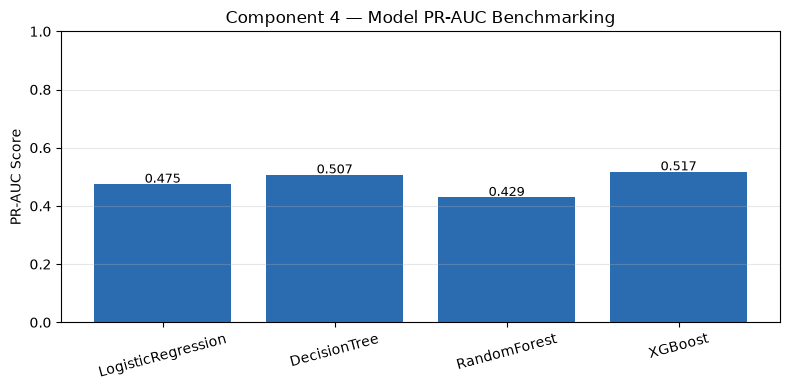

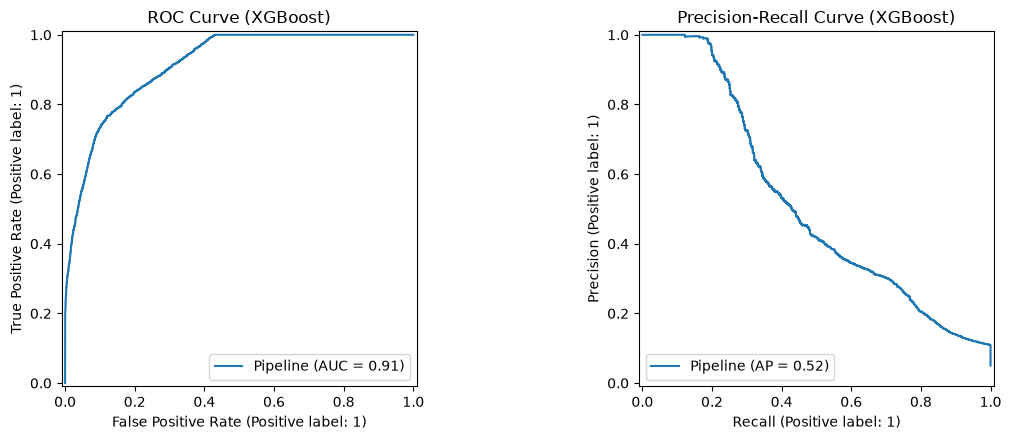

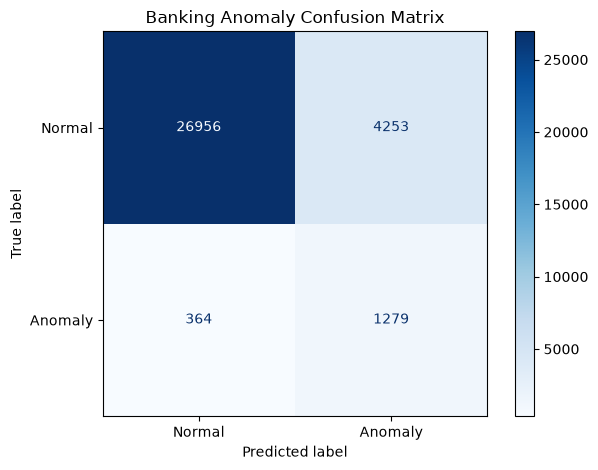

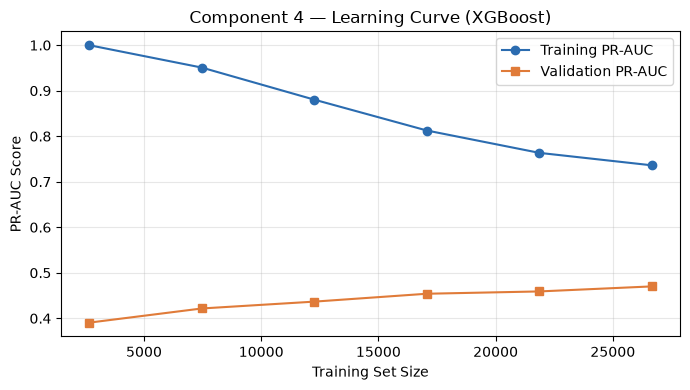

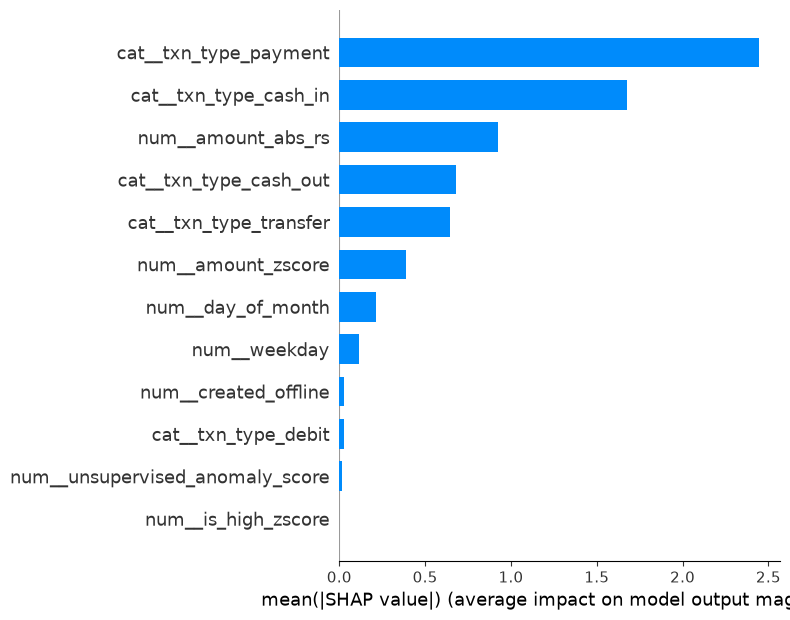

In [9]:
# =========================================================================
# STEP 7: VISUALIZATIONS & PERFORMANCE CHARTS
# =========================================================================

# --- Chart 1: Model PR-AUC Comparison Bar Chart ---
plt.figure(figsize=(8, 4))
bars = plt.bar(pr_auc_scores.keys(), pr_auc_scores.values(), color='#2b6cb0')
for b, v in zip(bars, pr_auc_scores.values()):
    plt.text(
        b.get_x() + b.get_width() / 2,
        v + 0.005,
        f'{v:.3f}',
        ha='center',
        fontsize=9,
    )
plt.ylim(0, 1.0)
plt.ylabel('PR-AUC Score')
plt.title('Component 4 — Model PR-AUC Benchmarking')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 2: ROC Curve & Precision-Recall Curve ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
RocCurveDisplay.from_estimator(champion_model, X_test, y_test, ax=axes[0])
axes[0].set_title(f'ROC Curve ({best_name})')

PrecisionRecallDisplay.from_estimator(
    champion_model, X_test, y_test, ax=axes[1]
)
axes[1].set_title(f'Precision-Recall Curve ({best_name})')
plt.tight_layout()
plt.show()

# --- Chart 3: Confusion Matrix ---
ConfusionMatrixDisplay.from_estimator(
    champion_model,
    X_test,
    y_test,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues',
)
plt.title('Banking Anomaly Confusion Matrix')
plt.tight_layout()
plt.show()

# --- Chart 4: Subsampled Learning Curve ---
sample_size = min(40000, len(X_train))
idx = np.random.RandomState(42).choice(len(X_train), sample_size, replace=False)

sizes, tr, val = learning_curve(
    champion_model,
    X_train.iloc[idx],
    y_train.iloc[idx],
    cv=StratifiedKFold(3, shuffle=True, random_state=42),
    scoring='average_precision',
    train_sizes=np.linspace(0.1, 1.0, 6),
    n_jobs=-1,
)

plt.figure(figsize=(7, 4))
plt.plot(sizes, tr.mean(1), 'o-', label='Training PR-AUC', color='#2b6cb0')
plt.plot(sizes, val.mean(1), 's-', label='Validation PR-AUC', color='#e07b39')
plt.xlabel('Training Set Size')
plt.ylabel('PR-AUC Score')
plt.title(f'Component 4 — Learning Curve ({best_name})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 5: SHAP Model Explainability Feature Importance ---
try:
    import shap

    # Transform test subset through pipeline preprocessor
    Xt = champion_model.named_steps['pre'].transform(X_test[:2000])
    Xt = Xt.toarray() if hasattr(Xt, 'toarray') else np.asarray(Xt)
    Xt = Xt.astype(float)

    feat_names = champion_model.named_steps['pre'].get_feature_names_out()
    explainer = shap.TreeExplainer(champion_model.named_steps['m'])
    shap_values = explainer.shap_values(Xt)

    plt.figure(figsize=(8, 4.5))
    if isinstance(shap_values, list):
        shap.summary_plot(
            shap_values[1],
            features=Xt,
            feature_names=feat_names,
            plot_type='bar',
            max_display=12,
        )
    else:
        shap.summary_plot(
            shap_values,
            features=Xt,
            feature_names=feat_names,
            plot_type='bar',
            max_display=12,
        )
except Exception as e:
    print(f'Notice: SHAP analysis skipped ({e}).')

## A8. Check: is this the same model as the saved `.pkl`?

The deployed app and the other notebooks use `component4_banking_anomaly_model.pkl`. If the retrained
model gives the same probabilities, every number below also describes the deployed model.

In [10]:
saved = joblib.load('archive/component4_banking_anomaly_model.pkl')
p_saved = saved['champion_model'].predict_proba(X_test[list(saved['champion_model'].feature_names_in_)])[:, 1]
diff = np.abs(p_saved - y_proba).max()
print(f'Largest difference between retrained and saved model probabilities: {diff:.6f}')
print('Same model as the saved .pkl' if diff < 1e-4 else
      'Different from the saved .pkl (library versions?) - the numbers below describe the RETRAINED model')

Largest difference between retrained and saved model probabilities: 0.000000
Same model as the saved .pkl


# Part B — Choose the decision threshold  *(from `agency_banking_threshold.ipynb`)*

The model outputs a **probability**. To turn it into "flag / don't flag" we need a cut-off (threshold).
The default 0.5 flags far too many normal customers, because `scale_pos_weight` pushes probabilities up.

The threshold is chosen on **out-of-fold** predictions of the training set: each training row gets a
probability from a copy of the model that did not see that row (5-fold CV). The test set is not used.

In [11]:
def summary(y_true, proba, t):
    flag = proba >= t
    tn, fp, fn, tp = confusion_matrix(y_true, flag).ravel()
    return {'threshold': round(float(t), 3),
            'precision': precision_score(y_true, flag), 'recall': recall_score(y_true, flag),
            'f1': f1_score(y_true, flag), 'flagged': int(flag.sum()),
            'false_alarms_per_1000_normal': fp / (fp + tn) * 1000}

s = summary(y_test, y_proba, 0.5)
print(f"At 0.5 on the test set: precision {s['precision']:.2f}, recall {s['recall']:.2f}, "
      f"{s['false_alarms_per_1000_normal']:.0f} false alarms per 1000 normal transactions")
print(f"-> of every 100 flagged transactions, about {100 - s['precision'] * 100:.0f} are normal customers.")

At 0.5 on the test set: precision 0.23, recall 0.78, 136 false alarms per 1000 normal transactions
-> of every 100 flagged transactions, about 77 are normal customers.


In [12]:
oof = cross_val_predict(clone(champion_model), X_train, y_train,
                        cv=StratifiedKFold(5, shuffle=True, random_state=42),
                        method='predict_proba', n_jobs=-1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best_f1_threshold = float(thr[np.nanargmax(f1_curve[:-1])])
THRESHOLD = round(best_f1_threshold, 2)

print(f'Out-of-fold PR-AUC     : {average_precision_score(y_train, oof):.3f}')
print(f'Threshold with max F1  : {best_f1_threshold:.3f}')
print(f'Chosen threshold       : {THRESHOLD}   (the app uses ANOMALY_THRESHOLD = 0.87)')

Out-of-fold PR-AUC     : 0.524
Threshold with max F1  : 0.866
Chosen threshold       : 0.87   (the app uses ANOMALY_THRESHOLD = 0.87)


## B2. Check the chosen threshold once on the test set

In [13]:
rows = []
for t in sorted({0.5, THRESHOLD, 0.9, 0.95}):
    tr = summary(y_train, oof, t); te = summary(y_test, y_proba, t)
    rows.append({'threshold': t,
                 'train OOF F1': tr['f1'],
                 'TEST precision': te['precision'], 'TEST recall': te['recall'], 'TEST F1': te['f1'],
                 'TEST false alarms / 1000 normal': te['false_alarms_per_1000_normal']})
pd.DataFrame(rows).set_index('threshold').round(2)

,train OOF F1,TEST precision,TEST recall,TEST F1,TEST false alarms / 1000 normal
threshold,,,,,
0.50,0.35,0.23,0.78,0.36,136.27
0.87,0.47,0.53,0.40,0.46,18.84
0.90,0.46,0.59,0.35,0.44,12.88
0.95,0.39,0.85,0.25,0.39,2.34


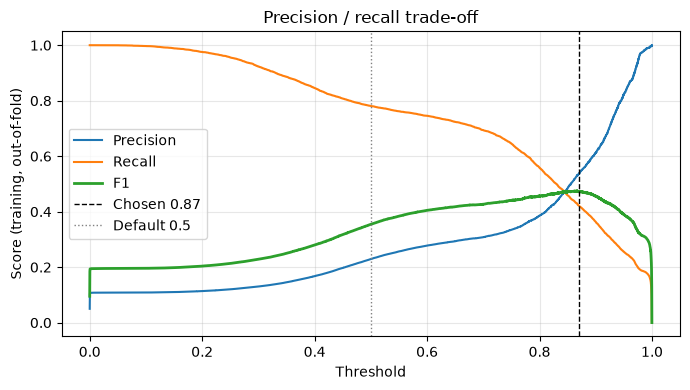

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thr, prec[:-1], label='Precision')
ax.plot(thr, rec[:-1], label='Recall')
ax.plot(thr, f1_curve[:-1], label='F1', lw=2)
ax.axvline(THRESHOLD, color='k', ls='--', lw=1, label=f'Chosen {THRESHOLD}')
ax.axvline(0.5, color='grey', ls=':', lw=1, label='Default 0.5')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score (training, out-of-fold)')
ax.set_title('Precision / recall trade-off'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## B3. Real-time advisory example  *(from `agency banking.ipynb`, step 8)*

*Change from the original:* the original used fixed 75 % / 45 % risk tiers, which do not match the
app. Here the transaction is flagged with the chosen threshold, exactly as `ml_service/app.py` does.

In [15]:
y_flag = (y_proba >= THRESHOLD).astype(int)
sample_idx = int(np.where(y_flag == 1)[0][0]) if y_flag.any() else 0
sample_txn = X_test.iloc[[sample_idx]].copy()
anomaly_score = round(float(champion_model.predict_proba(sample_txn)[0, 1]) * 100, 2)

print(f'Transaction Ref Index : {sample_idx}')
print(f'Calculated Fraud Risk : {anomaly_score}%  (flag if >= {THRESHOLD * 100:.0f}%)')
print('System Action Advice  :', 'FLAG - ask the agent to verify the customer' if anomaly_score >= THRESHOLD * 100
      else 'OK - normal transaction')
print(f'Actually an anomaly?  : {bool(y_test.iloc[sample_idx])}')

Transaction Ref Index : 46
Calculated Fraud Risk : 99.82%  (flag if >= 87%)
System Action Advice  : FLAG - ask the agent to verify the customer
Actually an anomaly?  : True


# Part C — Rules vs ML vs hybrid  *(from `agency_banking_hybrid.ipynb`)*

The live system flags a transaction when **ML says anomaly OR the amount reaches the CBSL daily limit**.
Is that justified? All methods are compared on the **same test set**; none of their settings is chosen on it.

| | Method | Flags a transaction when |
|---|---|---|
| N | Naive | it is a `transfer` |
| A | CBSL rule | amount ≥ CBSL rural-agent daily limit (deposit 50,000 · withdrawal 25,000 · transfer 50,000 LKR) |
| B | Z-score rule | the amount is unusual (abs z > 2) |
| C | ML, threshold 0.5 | the original default |
| D | ML, chosen threshold | from Part B |
| E | **Hybrid D OR A** | **what the live system does** |
| F | Hybrid D AND A | both agree |

In [16]:
print(df.groupby('txn_type')['target_anomaly'].agg(transactions='size', anomaly_rate='mean').round(3))

CBSL_LIMIT_RS = {'cash_in': 50_000, 'cash_out': 25_000, 'transfer': 50_000}
limit = X_test['txn_type'].map(CBSL_LIMIT_RS)
cbsl = (X_test['amount_abs_rs'] >= limit).to_numpy()          # payment / debit have no limit -> False
ml_t = y_proba >= THRESHOLD
y_true = y_test.to_numpy()

flags = {
    'N. Naive: every transfer':     (X_test['txn_type'] == 'transfer').to_numpy(),
    'A. CBSL rule only':            cbsl,
    'B. Z-score rule only':         (X_test['is_high_zscore'] == 1).to_numpy(),
    'C. ML only (0.5)':             y_proba >= 0.5,
    f'D. ML only ({THRESHOLD})':    ml_t,
    'E. Hybrid: ML OR CBSL (live)': ml_t | cbsl,
    'F. Hybrid: ML AND CBSL':       ml_t & cbsl,
}

          transactions  anomaly_rate
txn_type                            
cash_in          34663          0.00
cash_out         58723          0.07
debit              989          0.00
payment          52826          0.00
transfer         17059          0.24


## C1. Results

**Precision** = of the flagged, how many were real anomalies · **Recall** = of the real anomalies, how
many were flagged · **F1** = 2 × P × R / (P + R) · **False alarms per 1,000 normal** = how often an
honest customer is flagged.

In [17]:
def scores(y, flag):
    tn, fp, fn, tp = confusion_matrix(y, flag, labels=[0, 1]).ravel()
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    return {'TP': tp, 'FP': fp, 'FN': fn, 'precision': p, 'recall': r,
            'F1': 2 * p * r / (p + r) if p + r else 0.0,
            'false alarms / 1000 normal': fp / (fp + tn) * 1000, 'flagged %': (tp + fp) / len(y) * 100}

results = pd.DataFrame({k: scores(y_true, v) for k, v in flags.items()}).T.astype(float).round(3)
results

,TP,FP,FN,precision,recall,F1,false alarms / 1000 normal,flagged %
N. Naive: every transfer,820.0,2550.0,823.0,0.243,0.499,0.327,81.707,10.258
A. CBSL rule only,1500.0,18058.0,143.0,0.077,0.913,0.142,578.615,59.534
B. Z-score rule only,248.0,863.0,1395.0,0.223,0.151,0.180,27.652,3.382
C. ML only (0.5),1279.0,4253.0,364.0,0.231,0.778,0.357,136.275,16.839
D. ML only (0.87),664.0,588.0,979.0,0.530,0.404,0.459,18.841,3.811
E. Hybrid: ML OR CBSL (live),1574.0,18177.0,69.0,0.080,0.958,0.147,582.428,60.121
F. Hybrid: ML AND CBSL,590.0,469.0,1053.0,0.557,0.359,0.437,15.028,3.224


## C2. Is the difference real? Bootstrap 95 % confidence intervals (1,000 resamples)

In [18]:
rng = np.random.default_rng(42)
idx = rng.integers(0, len(y_true), size=(1000, len(y_true)))
yb = y_true.astype(bool)[idx]

def f1_boot(f):
    fb = np.asarray(f, dtype=bool)[idx]
    tp = (yb & fb).sum(1); fp = (~yb & fb).sum(1); fn = (yb & ~fb).sum(1)
    return 2 * tp / np.maximum(2 * tp + fp + fn, 1)

boot = {k: f1_boot(v) for k, v in flags.items()}
base = f'D. ML only ({THRESHOLD})'
for k in ['A. CBSL rule only', 'E. Hybrid: ML OR CBSL (live)', 'F. Hybrid: ML AND CBSL', 'N. Naive: every transfer']:
    d = boot[k] - boot[base]; lo, hi = np.percentile(d, [2.5, 97.5])
    print(f'F1({k}) - F1({base}): {d.mean():+.3f}  [{lo:+.3f}, {hi:+.3f}]')

F1(A. CBSL rule only) - F1(D. ML only (0.87)): -0.317  [-0.339, -0.294]
F1(E. Hybrid: ML OR CBSL (live)) - F1(D. ML only (0.87)): -0.311  [-0.333, -0.289]
F1(F. Hybrid: ML AND CBSL) - F1(D. ML only (0.87)): -0.022  [-0.032, -0.012]
F1(N. Naive: every transfer) - F1(D. ML only (0.87)): -0.132  [-0.158, -0.106]


## C3. What does the CBSL rule add to the ML model?

In [19]:
added = cbsl & ~ml_t
breakdown = (pd.DataFrame({'txn_type': X_test['txn_type'].to_numpy()[added], 'anomaly': y_true[added]})
             .groupby('txn_type')['anomaly'].agg(added_flags='size', real_anomalies='sum'))
breakdown['false_alarms'] = breakdown['added_flags'] - breakdown['real_anomalies']
print(f'The hybrid adds {added.sum()} flags: {y_true[added].sum()} real anomalies, '
      f'{(1 - y_true[added]).sum()} honest customers.')
breakdown

The hybrid adds 18499 flags: 910 real anomalies, 17589 honest customers.


,added_flags,real_anomalies,false_alarms
txn_type,,,
cash_in,5729,0,5729
cash_out,10266,413,9853
transfer,2504,497,2007


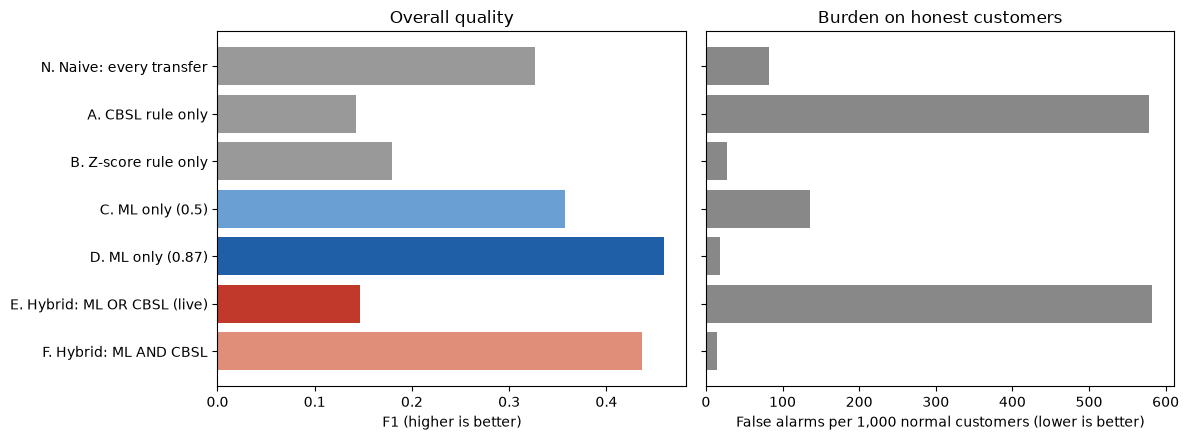

In [20]:
r = results.loc[list(flags)]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].barh(r.index, r['F1'], color=['#999'] * 3 + ['#6a9fd4', '#1f5fa8', '#c0392b', '#e08e79'])
ax[0].set_xlabel('F1 (higher is better)'); ax[0].invert_yaxis(); ax[0].set_title('Overall quality')
ax[1].barh(r.index, r['false alarms / 1000 normal'], color='#888')
ax[1].set_xlabel('False alarms per 1,000 normal customers (lower is better)'); ax[1].invert_yaxis()
ax[1].set_yticklabels([]); ax[1].set_title('Burden on honest customers')
plt.tight_layout(); plt.savefig('banking_anomaly_detection_pipeline.png', dpi=120); plt.show()

# Part D — Training/serving check

The app computes the model inputs in `buildAnomalyFeatures` (`backend/src/utils/features.js`).
In the training data, `amount_zscore` is the amount standardised **within its transaction type**
(a deposit compared with deposits, a withdrawal with withdrawals):

In [21]:
m = df.groupby('txn_type')['amount_abs_rs'].transform('mean')
s = df.groupby('txn_type')['amount_abs_rs'].transform('std')
match = (((df['amount_abs_rs'] - m) / s - df['amount_zscore']).abs() < 0.02).mean()
print(f'amount_zscore == (amount - mean of its type) / std of its type: {match:.3f}')

amount_zscore == (amount - mean of its type) / std of its type: 1.000


*Fix in the app:* the backend first compared a transaction with **all** of the agent's recent transactions,
every type mixed together. It now compares it only with the agent's recent transactions **of the same type**,
matching the training data. (The mean and spread come from the agent's own history, not from PaySim,
because PaySim amounts are on a much larger scale than a rural agent's.)

`unsupervised_anomaly_score` is computed by the ML service with the saved Isolation Forest, as in training.

# Part E — Save the model  *(from `agency banking.ipynb`, step 9)*

*Change from the original:* saved as `banking_anomaly_model.pkl`, with the chosen threshold inside, so the
original notebook's `component4_banking_anomaly_model.pkl` is not overwritten. A copy of this file is the
app's model (`ml_service/models/banking_anomaly_model.pkl`).

In [22]:
# =========================================================================
# STEP 9: MODEL ARTIFACT SERIALIZATION (SAVING PIPELINE & IMPUTER)
# =========================================================================
# Save champion model pipeline and isolation forest artifacts for API deployment
artifacts = {
    'champion_model': champion_model,
    'iso_imputer': iso_imputer,
    'iso_forest': iso_forest,
    'iso_num_cols': iso_num_cols,
    'threshold': THRESHOLD,
}

model_filename = 'banking_anomaly_model.pkl'
joblib.dump(artifacts, model_filename)
print(f'\n✅ Upgraded Model saved successfully as "{model_filename}"')


✅ Upgraded Model saved successfully as "banking_anomaly_model.pkl"


# Conclusion

*Written after reading the numbers above — fill in with the actual results:*

- Champion model: ___ (PR-AUC ___). Threshold chosen on training data: ___.
- At that threshold on the test set: precision ___, recall ___, F1 ___, ___ false alarms per 1,000 normal.
- Rules alone: F1 ___. Live hybrid (ML OR CBSL): F1 ___ (interval ___).
- Design decision: ___

**Limitations.** PaySim is a simulated mobile-money dataset, not Sri Lankan agency-banking records; its
amounts are much larger than rural agent transactions, which affects how often the CBSL rule fires.
The Isolation Forest feature adds almost nothing (see SHAP in A7).The comparison of methods on
the same data is valid; the absolute numbers are not a claim about real-world performance.